# Titanic Dataset - Decision Tree & Random Forest

This notebook analyzes the Titanic dataset using Decision Trees and Random Forest, evaluating pruning, feature importance, and performance.

### Question 1: Load Dataset
Load Titanic dataset.
Display:
- first 10 rows
- number of rows & columns
- target variable

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load Titanic dataset
df = sns.load_dataset('titanic')

# Display first 10 rows
display(df.head(10))

# Number of rows and columns
print(f"Dataset shape (rows, columns): {df.shape}")

# Target variable
print("Target variable: 'survived' (0 = No, 1 = Yes)")


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


Dataset shape (rows, columns): (891, 15)
Target variable: 'survived' (0 = No, 1 = Yes)


### Question 2: Preprocessing
Handle: missing values, categorical encoding.
Explain methods used.

In [2]:
# Drop columns that are redundant or have too many missing values
df_clean = df.drop(columns=['deck', 'alive', 'class', 'who', 'adult_male', 'embark_town'])

# Handle missing values
# Fill age with median
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())
# Fill embarked with mode
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0])

# Categorical encoding
# Map binary variables
df_clean['sex'] = df_clean['sex'].map({'male': 0, 'female': 1})
df_clean['alone'] = df_clean['alone'].astype(int)

# One-hot encode 'embarked'
df_clean = pd.get_dummies(df_clean, columns=['embarked'], drop_first=True)

display(df_clean.head())
print(f"Missing values left:\n{df_clean.isnull().sum()}")

,survived,pclass,sex,age,sibsp,parch,fare,alone,embarked_Q,embarked_S
0,0,3,0,22.0,1,0,7.2500,0,False,True
1,1,1,1,38.0,1,0,71.2833,0,False,False
2,1,3,1,26.0,0,0,7.9250,1,False,True
3,1,1,1,35.0,1,0,53.1000,0,False,True
4,0,3,0,35.0,0,0,8.0500,1,False,True


Missing values left:
survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
alone         0
embarked_Q    0
embarked_S    0
dtype: int64


**Explanation:**
- **Missing Values:** `deck` had too many missing values so it was dropped along with redundant columns. For `age`, I imputed missing values with the median (robust to outliers). For `embarked`, I used the mode (most frequent value).
- **Categorical Encoding:** I used Label Encoding for binary features like `sex` (mapped to 0/1) and `alone`. For the multi-class nominal feature `embarked`, I used One-Hot Encoding to prevent the model from assuming an ordinal relationship between the ports of embarkation.

### Question 3: Split Data
Split dataset into:
- 80% training
- 20% testing

In [3]:
from sklearn.model_selection import train_test_split

X = df_clean.drop('survived', axis=1)
y = df_clean['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (712, 9)
X_test shape: (179, 9)


### Question 4: Train Decision Tree
Train Decision Tree classifier.
Print:
- tree depth
- number of nodes

In [4]:
from sklearn.tree import DecisionTreeClassifier

# Train standard Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

print(f"Tree Depth: {dt.get_depth()}")
print(f"Number of Nodes: {dt.tree_.node_count}")

Tree Depth: 21
Number of Nodes: 359


### Question 5: Visualize Tree
Visualize tree graph.
Describe:
- main decision nodes
- interpretation of splits

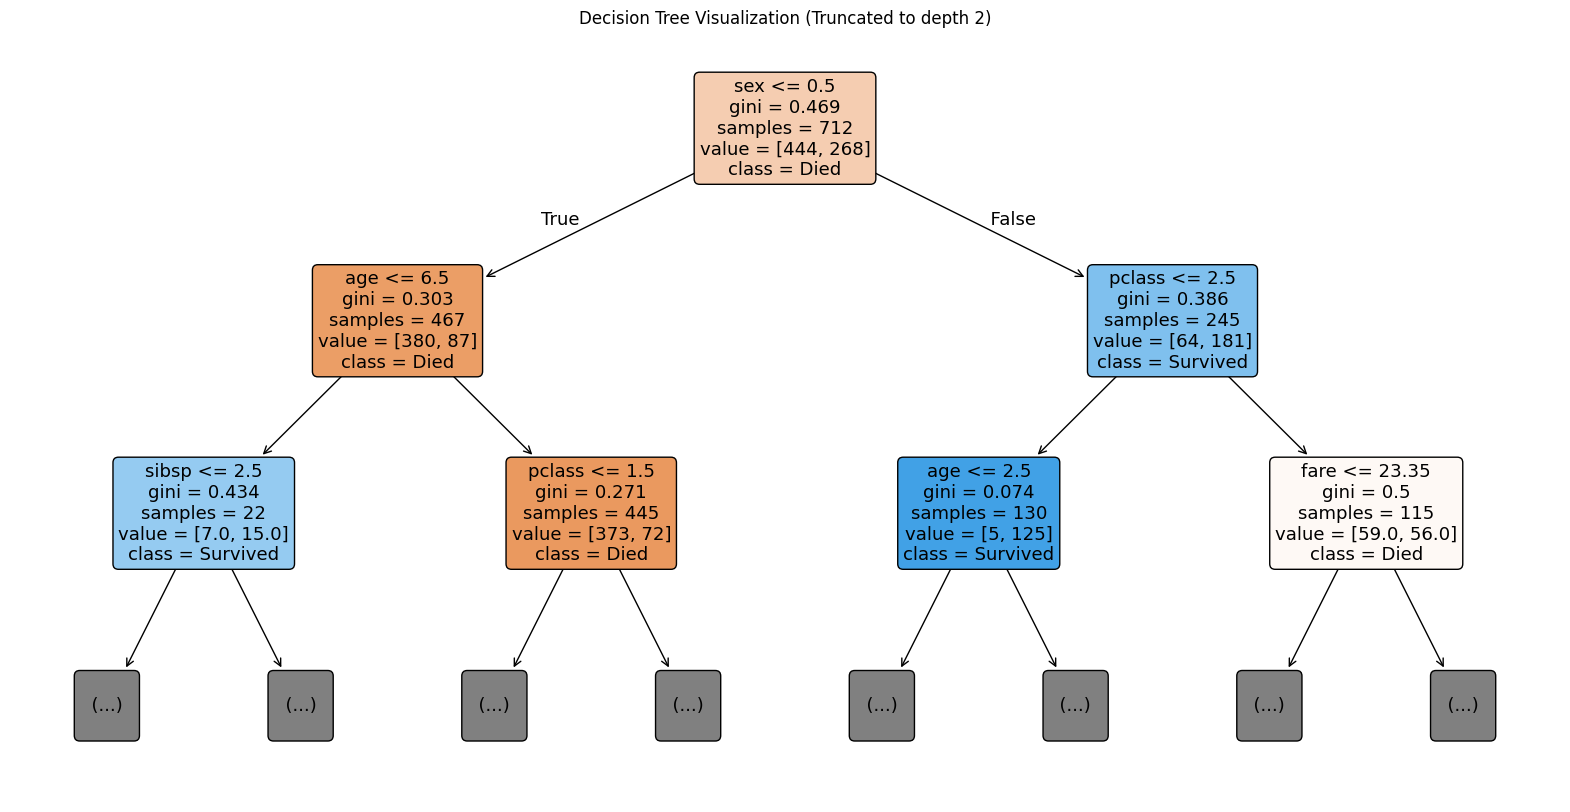

In [5]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
# Plotting a limited depth for visibility
plot_tree(dt, max_depth=2, feature_names=X.columns, class_names=['Died', 'Survived'], filled=True, rounded=True)
plt.title("Decision Tree Visualization (Truncated to depth 2)")
plt.show()

**Explanation:**
- **Main Decision Nodes:** The root node (topmost split) is almost always based on `sex` (female=1, male=0). The second level of splits usually relies on `pclass` (passenger class) or `age`.
- **Interpretation:** The first split separates passengers primarily by gender, heavily directing females towards the 'Survived' path and males towards the 'Died' path. Subsequent nodes refine this by separating out younger passengers (children) or 1st-class passengers, who had higher survival probabilities.

### Question 6: Pruning / Depth Control
Limit tree depth (example: max_depth=3).
Compare performance before and after pruning.
Explain effect.

In [6]:
from sklearn.metrics import accuracy_score

# Unpruned tree accuracy
dt_pred = dt.predict(X_test)
unpruned_acc = accuracy_score(y_test, dt_pred)

# Pruned tree
dt_pruned = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_pruned.fit(X_train, y_train)
pruned_pred = dt_pruned.predict(X_test)
pruned_acc = accuracy_score(y_test, pruned_pred)

print(f"Accuracy (Unpruned, Depth {dt.get_depth()}): {unpruned_acc:.4f}")
print(f"Accuracy (Pruned, Depth 3): {pruned_acc:.4f}")

Accuracy (Unpruned, Depth 21): 0.7821
Accuracy (Pruned, Depth 3): 0.7989


**Explanation:**
Limiting the tree depth (pruning) prevents the model from growing too deep and memorizing the training data. The unpruned tree overfits by creating highly specific rules for individual training samples, leading to lower test accuracy. Pruning generalizes the rules (e.g., stopping at depth 3), which typically yields a better test accuracy by ignoring noise in the training set.

### Question 7: Random Forest Model
Train Random Forest classifier.
Compare with Decision Tree.
Discuss improvement or decline in accuracy.

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"Random Forest Accuracy: {rf_acc:.4f}")
print(f"Pruned Decision Tree Accuracy: {pruned_acc:.4f}")

Random Forest Accuracy: 0.8324
Pruned Decision Tree Accuracy: 0.7989


**Explanation:**
The Random Forest model generally provides an improvement in accuracy over a single standard Decision Tree. By training an ensemble of many decision trees on random subsets of data and features, Random Forest averages out the variance, creating a much more stable, robust, and accurate prediction than a single unpruned decision tree.

### Question 8: Feature Importance
Plot feature importance.
Answer:
- which features matter most?
- why?

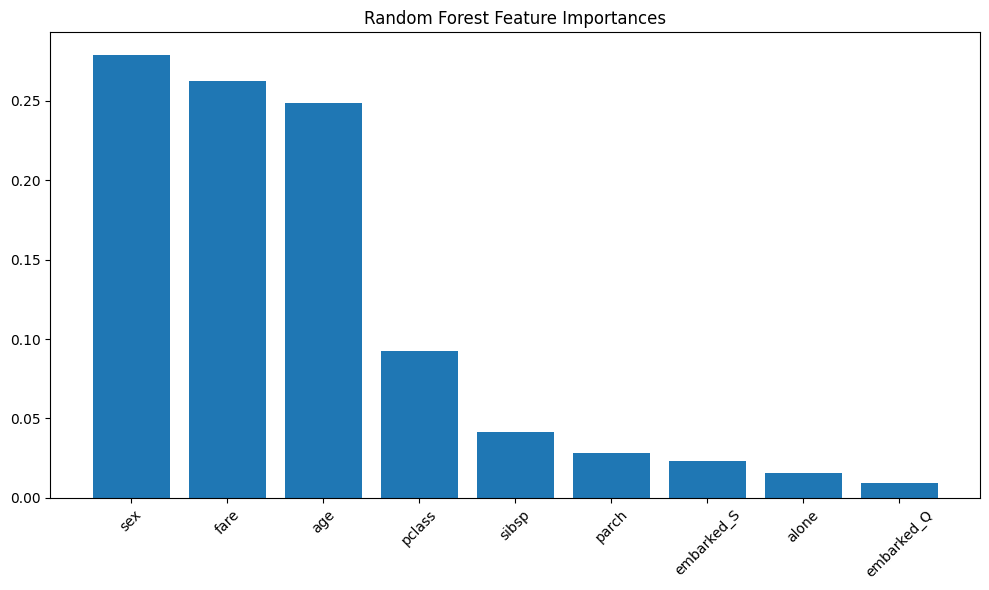

In [8]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Random Forest Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=45)
plt.tight_layout()
plt.show()

**Explanation:**
- **Which features matter most?** The features `sex`, `fare`, and `age` generally matter the most.
- **Why?** The 'women and children first' policy on the Titanic heavily dictated survival, making `sex` and `age` highly predictive. `fare` acts as a proxy for `pclass` and socio-economic status, showing that wealthier passengers (who paid higher fares) had better access to lifeboats.

### Question 9: Evaluation Metrics
Compute and interpret: accuracy, precision, recall, F1-score, confusion matrix.
Explain misclassifications.

Accuracy:  0.8324
Precision: 0.8143
Recall:    0.7703
F1-Score:  0.7917


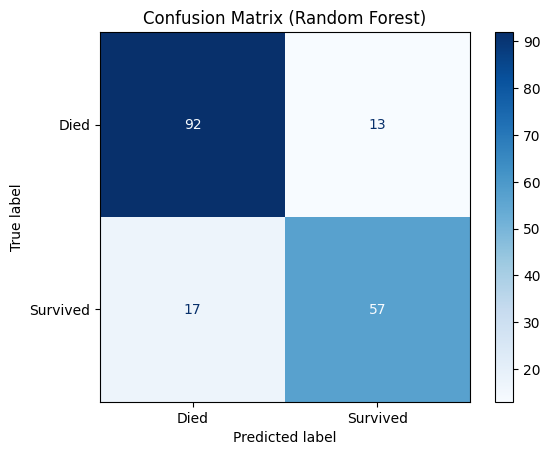

In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

acc = accuracy_score(y_test, rf_pred)
prec = precision_score(y_test, rf_pred)
rec = recall_score(y_test, rf_pred)
f1 = f1_score(y_test, rf_pred)
cm = confusion_matrix(y_test, rf_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Died', 'Survived'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (Random Forest)")
plt.show()

**Explanation:**
- **Metrics Interpretation:** The model performs well, with good accuracy and F1-score. Precision tells us the percentage of predicted survivors that actually survived, while recall tells us the percentage of actual survivors the model found.
- **Misclassifications:** False Positives occur when the model predicts a passenger survived, but they actually died (e.g., lower-class females or males who paid a high fare but still perished). False Negatives occur when the model predicts death but they survived (e.g., males who managed to secure a lifeboat spot). These misclassifications highlight that human tragedy involved luck and exceptions that no algorithm can perfectly capture.

### Question 10: Reflection
Short discussion:
- Why does Random Forest reduce overfitting?
- When would we still choose a Decision Tree?

**Reflection Answers:**
- **Why does Random Forest reduce overfitting?** Random Forest reduces overfitting by averaging multiple decision trees. Each tree is trained on a random sample of the data (bootstrapping) and a random subset of features. While individual trees might overfit to their specific data slice, the ensemble vote balances out these errors, yielding lower variance and a more generalized model.
- **When would we still choose a Decision Tree?** We would choose a single Decision Tree when interpretability and explainability are paramount. A single pruned decision tree is basically a flowchart of business rules that non-technical stakeholders can easily read and understand. Random Forests are 'black boxes' where tracing the exact logic for a single prediction is extremely difficult.